# Generate wind history for a larger farm and covering 1 week of simulated time

Generate a wind history for demonstration using the example FLORIS model

In [80]:
import floris.layout_visualization as layoutviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from floris import FlorisModel
from scipy import stats

## Parameters

In [81]:
dt = 1.0  # [s]
N = 60 * 60 * 24 * 8  # 1 week + 1 Day


# Weibull parameters for wind speed distribution
shape_parameter = 2.0  
scale_parameter = 8.0  

In [82]:
# Read in the FLORIS model
fmodel = FlorisModel("floris_input_large.yaml")

## Show the layout

Text(0.5, 1.0, 'Example farm layout')

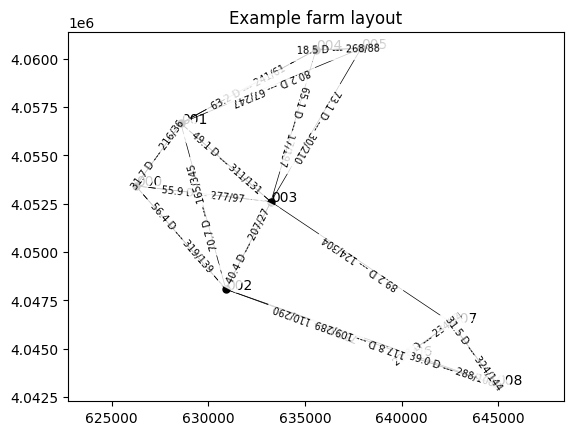

In [83]:
fig, ax = plt.subplots()
layoutviz.plot_turbine_points(fmodel, ax=ax)
layoutviz.plot_turbine_labels(fmodel, ax=ax)
layoutviz.plot_waking_directions(fmodel, ax=ax, limit_num=3)
ax.set_title("Example farm layout")

## Add a stylized delay proportional to distance along x-axis from turbine 0

In [84]:
layout_x = fmodel.layout_x
delay_array = ((layout_x - layout_x[0]) / 10.0).astype(int)
delay_array

array([   0,  233,  466,  699,  932, 1165, 1398, 1631, 1865])

In [85]:
# Set random seed
np.random.seed(10)

step_size = 0.05
n_iterations = 5

# Step 1: Generate random walk
steps = np.random.normal(0, step_size, N)
walk = np.cumsum(steps)

# Step 2: Transform to uniform [0,1] using CDF
walk_uniform = stats.norm.cdf(walk, np.mean(walk), np.std(walk))

# Step 3: Transform uniform to Weibull using inverse CDF
ws_u_inf = scale_parameter * (-np.log(1 - walk_uniform))**(1/shape_parameter)

# Step 4: Iterative smoothing to reduce abrupt changes while preserving distribution
for _ in range(n_iterations):
    # Apply light smoothing
    wind_smooth = np.convolve(ws_u_inf, [0.25, 0.5, 0.25], mode='same')
    
    # Re-rank to preserve exact Weibull distribution
    sorted_indices = np.argsort(wind_smooth)
    target_values = np.sort(ws_u_inf)  # Original Weibull values
    ws_u_inf[sorted_indices] = target_values
    

# Use constant wind direction
wd_inf = 270.0 * np.ones(N)



## Generate the histories

Text(0.5, 0, 'Time step')

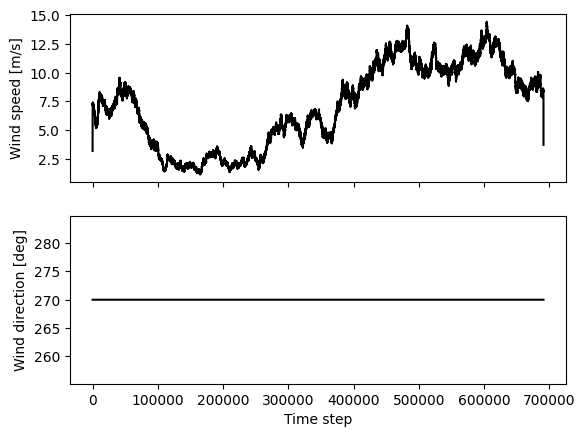

In [86]:
# Plot the histories
fig, axarr = plt.subplots(2, 1, sharex=True)
axarr[0].plot(ws_u_inf, color="k")
axarr[0].set_ylabel("Wind speed [m/s]")
axarr[1].plot(wd_inf, color="k")
axarr[1].set_ylabel("Wind direction [deg]")
axarr[1].set_xlabel("Time step")

## Convert to individual turbine histories

Text(0.5, 0, 'Time step')

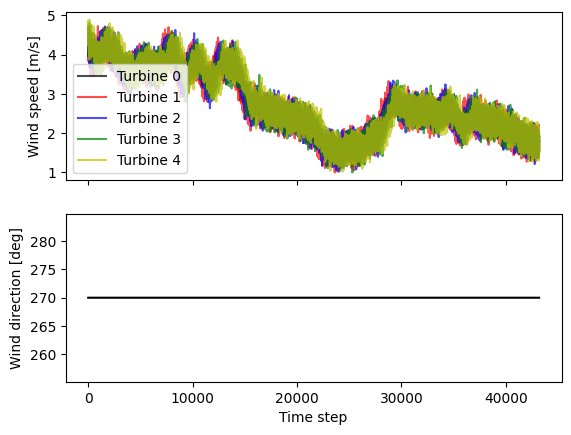

In [87]:
# Set turbine 0 history equal to original
ws_turbines = np.zeros((N, fmodel.n_turbines))

ws_turbines[:,0] = ws_u_inf


# For the remaining turbines
# a) Add random noise
# b) Time shift by the delay amount
for i in range(1, fmodel.n_turbines):
    ws_turbines[:,i] = ws_u_inf + 0.15 * np.random.randn(N)
    ws_turbines[:,i] = np.roll(ws_turbines[:,i], delay_array[i])

# Drop 1 day from ws_turbines and wd_inf to remove effect of roll from beginning
drop_index = 60 * 60 * 24
ws_turbines_drop = ws_turbines[drop_index:,:]
wd_inf_drop = wd_inf[drop_index:]

# Plot the first half day of wind speeds for the first 5 turbines
fig, axarr = plt.subplots(2, 1, sharex=True)
t = np.arange(60 * 60 * 12)  # First day 
for i, color, label in zip(range(5), ["k", "r", "b", "g", "y"], ["Turbine 0", "Turbine 1", "Turbine 2", "Turbine 3", "Turbine 4"]):
    axarr[0].plot(t, ws_turbines_drop[:len(t), i], color=color, label=label, alpha=0.7)
axarr[0].set_ylabel("Wind speed [m/s]")
axarr[0].legend()
axarr[1].plot(t, wd_inf_drop[:len(t)], color="k")
axarr[1].set_ylabel("Wind direction [deg]")
axarr[1].set_xlabel("Time step")



## Set up time_utc such that the data is from April 2020

In [89]:
time_utc = pd.date_range(start="2020/4/1", periods=N, freq="1s")

Text(0.5, 0, 'Time step')

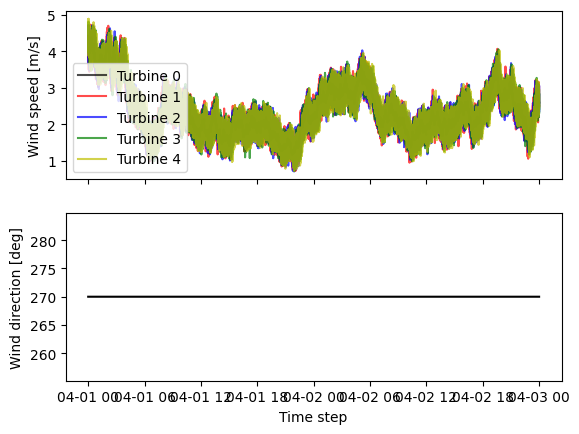

In [92]:
# Plot the first half day of wind speeds for the first 5 turbines
fig, axarr = plt.subplots(2, 1, sharex=True)
t_idx = range(60 * 60 * 48)  # First day 
for i, color, label in zip(range(5), ["k", "r", "b", "g", "y"], ["Turbine 0", "Turbine 1", "Turbine 2", "Turbine 3", "Turbine 4"]):
    axarr[0].plot(time_utc[t_idx], ws_turbines_drop[t_idx, i], color=color, label=label, alpha=0.7)
axarr[0].set_ylabel("Wind speed [m/s]")
axarr[0].legend()
axarr[1].plot(time_utc[t_idx], wd_inf_drop[t_idx], color="k")
axarr[1].set_ylabel("Wind direction [deg]")
axarr[1].set_xlabel("Time step")

## Add histories to dataframe and save as feather

In [93]:
df = pd.DataFrame(
    {
        "time": np.arange(N) * dt,
        "time_utc": pd.date_range(start="1/1/2020", periods=N, freq="1s"),
        "wd_mean": wd_inf,
    }
)

for i in range(fmodel.n_turbines):
    df[f"ws_{i:03d}"] = ws_turbines[:,i]

# Save to feather

df.to_feather("wind_input_large.ftr")